# Case 7 — Can We Trust the Highlight?
### Auditing attention explanations with real SST-2 data

**Stakeholder story (hypothetical):** a review platform predicts positive or negative
sentiment and wants to show highlighted words as the reason for its decision.
**Audit question:** what claim about those highlights can the evidence justify?

In Case 6 we examined highlighted image regions. Here we examine highlighted text
positions, including weights from inside the prediction mechanism itself.
Being internal to a model does not automatically make a signal a complete explanation.

**Learning outcomes:** explain attention pooling; distinguish correctness, confidence,
plausibility and faithfulness; compare attribution diagnostics; separate input from
fixed-hidden-state interventions; summarize evidence and its limits.

**Prerequisites:** train/evaluation separation, classification scores, basic gradients.
Core lesson: 90 minutes. Optional mechanism/robustness extension: 30 minutes.
Run top to bottom. The supplied checkpoint avoids training during class.

**Opening prediction:** would a correct label and a sensible-looking highlight be enough
to tell a user, “The model decided this because of these words”? Write your answer first.

In [1]:
from pathlib import Path
import json, sys, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p/'audit_pipeline.py').exists()), None)
if ROOT is None:
    raise FileNotFoundError('Extract the whole package and open the notebook inside it.')
sys.path.insert(0,str(ROOT))
import case7_attention_audit as audit
from audit_pipeline import load_model, token_audit, attention_audit, CONFIG, tensors
torch.set_num_threads(2)
OUT=ROOT/'outputs'
model,vocab=load_model(ROOT,2026)
train=pd.read_csv(OUT/'training_subset.csv')
validation=pd.read_csv(ROOT/'data/sst2_validation.csv')
pred=pd.read_json(OUT/'validation_predictions_seed2026.jsonl',lines=True)
aggregate=pd.read_csv(OUT/'audit_seed2026.csv')
trials=pd.read_csv(OUT/'interventions_seed2026.csv')
metrics=pd.DataFrame(json.loads((OUT/'predictive_metrics.json').read_text()))
quality=json.loads((OUT/'data_quality.json').read_text())
print('Loaded model seed 2026; label 0 = negative, label 1 = positive.')
print('Fixed classroom configuration:', CONFIG)

Loaded model seed 2026; label 0 = negative, label 1 = positive.
Fixed classroom configuration: {'train_n': 20000, 'max_len': 80, 'epochs': 4, 'batch': 128, 'emb_dim': 64, 'hidden_dim': 48, 'dropout': 0.25, 'audit_n': 120, 'shuffles': 30}


## 1. Establish the data and prediction contract

SST-2 contains movie-review text. Official training includes short labeled fragments;
official validation has sentence-level examples. Our fixed sample contains 20,000 cleaned
training rows. The vocabulary and TF-IDF baseline are fitted only on those rows.

We remove normalized training duplicates and conflicting-label keys, and exclude any
exact training/validation overlap. This is **not** a near-duplicate or source-review audit.
Related fragments may remain. We do not randomly split fragments for early stopping.
All models train for four fixed epochs; the three seeds use the same data and recipe.

The 872 labeled validation examples support evaluation and exploratory lesson development.
They are not a fresh confirmation set after this development. Hidden public test labels
are not used. No claim of production readiness follows from this benchmark.

,value
original_train,67349.000000
original_validation,872.000000
train_duplicate_rows,371.000000
conflicting_train_keys,5.000000
cross_split_exact_keys_removed,0.000000
validation_duplicate_rows,0.000000
clean_training_pool,66973.000000
selected_training_rows,20000.000000
vocab_size,9649.000000
validation_unknown_rate,0.070158


,train_count,validation_count
label,,
0,8852,428
1,11148,444


,training token length
0.50,7.0
0.90,23.0
0.95,28.0
0.99,38.0
1.00,54.0


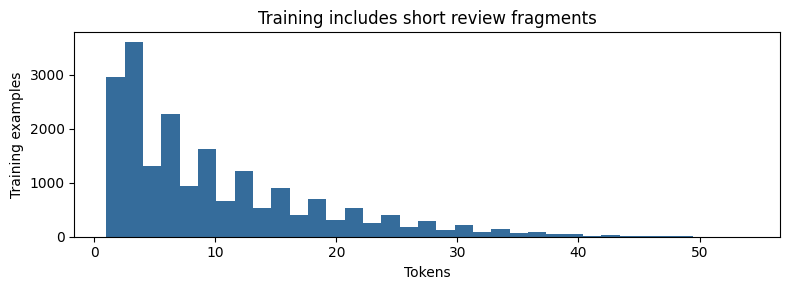

In [2]:
display(pd.Series(quality,name='value').to_frame())
display(pd.DataFrame({'train_count':train.label.value_counts(),
                      'validation_count':validation.label.value_counts()}).sort_index())
lengths=train.sentence.map(lambda s:len(audit.simple_tokenize(s)))
display(lengths.quantile([.5,.9,.95,.99,1]).rename('training token length').to_frame())
fig,ax=plt.subplots(figsize=(8,3))
ax.hist(lengths,bins=35,color='#356c9b');ax.set(xlabel='Tokens',ylabel='Training examples',title='Training includes short review fragments')
plt.tight_layout();plt.show()

**Checkpoint:** distinguish a duplicate check from evidence that every example is independent.
What might the fragment/sentence difference do to model performance?

## 2. Establish predictive competence

Compare the attention model with a class-prior baseline and TF-IDF logistic regression
trained on the same subset. A deeper model need not win. Explanation auditing remains
useful for a competent but imperfect model; do not interpret it as a deployment endorsement.
Accuracy measures agreement with reference labels. Log loss also penalizes confident errors;
it is not, by itself, a calibration assessment.

In [3]:
display(metrics.drop(columns='confusion_matrix').round(4))
cm=np.asarray(metrics.loc[metrics.model=='BiLSTM attention seed 2026','confusion_matrix'].iloc[0])
display(pd.DataFrame(cm,index=['reference negative','reference positive'],columns=['predicted negative','predicted positive']))
majority=float(metrics.iloc[0].accuracy)
if float(metrics.loc[metrics.model=='BiLSTM attention seed 2026','accuracy'].iloc[0]) <= majority+.10:
    raise RuntimeError('Predictive competence gate failed: investigate before explaining.')
print('Competence gate passed: >10 percentage points above majority (a teaching threshold, not a deployment standard).')

Competence gate passed: >10 percentage points above majority (a teaching threshold, not a deployment standard).


,model,accuracy,balanced_accuracy,log_loss
0,majority / class prior,0.5092,0.5000,0.6977
1,TF-IDF logistic regression,0.7901,0.7892,0.4647
2,BiLSTM attention seed 2026,0.7764,0.7753,0.6469
3,BiLSTM attention seed 2027,0.7901,0.7894,0.5682
4,BiLSTM attention seed 2028,0.7787,0.7775,0.6454


,predicted negative,predicted positive
reference negative,306,122
reference positive,73,371


## 3. Understand the mechanism before interpreting it

Tokens become IDs and embeddings. A bidirectional LSTM produces contextual states
$h_i$: the state at one position can encode information from other words.
Additive attention gives $\alpha_i=\mathrm{softmax}(v^T\tanh(Wh_i+b))$.
The classifier uses $c=\sum_i\alpha_i h_i$ and logits $z=W_c c+b_c$.

Padding is masked. At most 80 tokens are used. Unknown words share one learned embedding.
This is one attention-pooling distribution, not transformer self-attention.

**High attention means:** a larger pooling weight for that contextual state.
It does not directly specify that word's signed contribution to a class.

First select a correct example with 6–35 tokens and confidence 0.80–0.97, nearest 0.90.
This is an inspectable example, not evidence that its explanation is good. If the preferred
pool is empty, the code transparently falls back to another correct example.

Review: uncommonly stylish but equally silly ... the picture fails to generate much suspense , nor does it ask searching enough questions to justify its pretensions . 
Reference: 0 prediction: 0 probability: 0.8998


,position,token,token_id,is_unknown,attention
0,0,uncommonly,2169,False,0.171752
1,1,stylish,638,False,0.109452
2,2,but,27,False,0.000425
3,3,equally,1009,False,0.001004
4,4,silly,380,False,0.000661
5,5,.,7,False,0.000047
6,6,.,7,False,0.000016
7,7,.,7,False,0.000008
8,8,the,2,False,0.000030
9,9,picture,195,False,0.001553


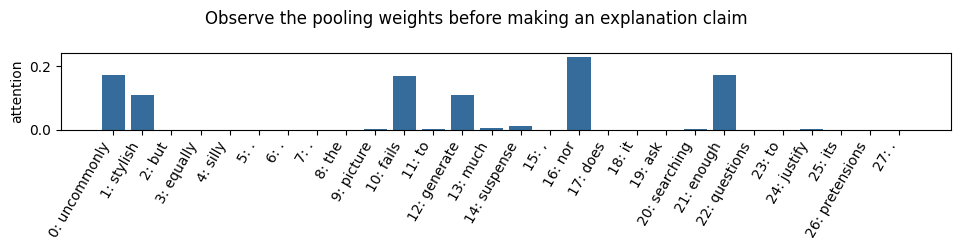

In [4]:
pred['n_tokens']=pred.tokens.map(len)
pool=pred[pred.correct & pred.n_tokens.between(6,35) & pred.confidence.between(.8,.97)].copy()
if pool.empty:
    print('Preferred example pool empty; falling back to all correct examples.')
    pool=pred[pred.correct].copy()
if pool.empty: raise RuntimeError('No correct examples available; inspect the model.')
pool['distance']=(pool.confidence-.90).abs()
first=pool.sort_values(['distance','idx']).iloc[0]
table,info=token_audit(model,first.sentence,vocab)
print('Review:',first.sentence)
print('Reference:',first.label,'prediction:',info['target'],'probability:',round(info['target_probability'],4))
display(table[['position','token','token_id','is_unknown','attention']])
def plot_tokens(t,columns,title):
    fig,axes=plt.subplots(len(columns),1,figsize=(max(9,min(16,len(t)*.35)),2.5*len(columns)),squeeze=False)
    for ax,col in zip(axes[:,0],columns):
        ax.bar(np.arange(len(t)),t[col],color='#356c9b')
        ax.set_xticks(np.arange(len(t)),[f'{i}: {w}' for i,w in zip(t.position,t.token)],rotation=60,ha='right')
        ax.set_ylabel(col.replace('_',' '));ax.axhline(0,color='black',lw=.6)
    fig.suptitle(title);fig.tight_layout();plt.show()
plot_tokens(table,['attention'],'Observe the pooling weights before making an explanation claim')

**Stop and write:** one observation, one hypothesis, and one claim requiring stronger evidence.
Example observation: “Position 5 receives more pooling weight than position 2.”
Do not yet substitute “causes the prediction.”

## 4. Compare three different questions

We use the originally predicted class throughout. Its **margin** is its logit minus the
other class's logit. Positive margin favors that class; its probability is sigmoid(margin).

| Diagnostic | Question | Limitation |
|---|---|---|
| Attention | Which contextual states receive pooling weight? | Not signed word importance |
| Gradient × embedding magnitude | Where is the margin locally sensitive, scaled by the embedding? | Local, representation-dependent, unsigned |
| Single-token UNK replacement | How does the margin change when this token ID is replaced? | Changes context; may create unnatural input |

Gradient magnitude is the sum of absolute componentwise gradient × embedding products,
normalized across positions. It is **not** the absolute value of a signed sum. We differentiate
the class margin to match the intervention target. Rankings use absolute replacement effects;
the signed drops remain visible: a negative drop means replacement increased the target margin.
No diagnostic is ground truth.

Attention–gradient Spearman: 0.705
Attention–|replacement| Spearman: 0.286
Gradient–|replacement| Spearman: 0.62
Top-3 overlap: 0.333


,position,token,attention,gradient_magnitude,replacement_margin_drop,replacement_probability_drop
0,0,uncommonly,0.1718,0.0816,-1.2467,-0.0692
1,1,stylish,0.1095,0.0638,-0.9555,-0.0591
2,2,but,0.0004,0.0387,0.2308,0.0228
3,3,equally,0.0010,0.0513,0.7934,0.0973
4,4,silly,0.0007,0.0364,1.5799,0.2506
5,5,.,0.0000,0.0198,0.8861,0.1124
6,6,.,0.0000,0.0152,0.9848,0.1294
7,7,.,0.0000,0.0221,1.3269,0.1954
8,8,the,0.0000,0.0403,1.7493,0.2901
9,9,picture,0.0016,0.0608,0.8507,0.1066


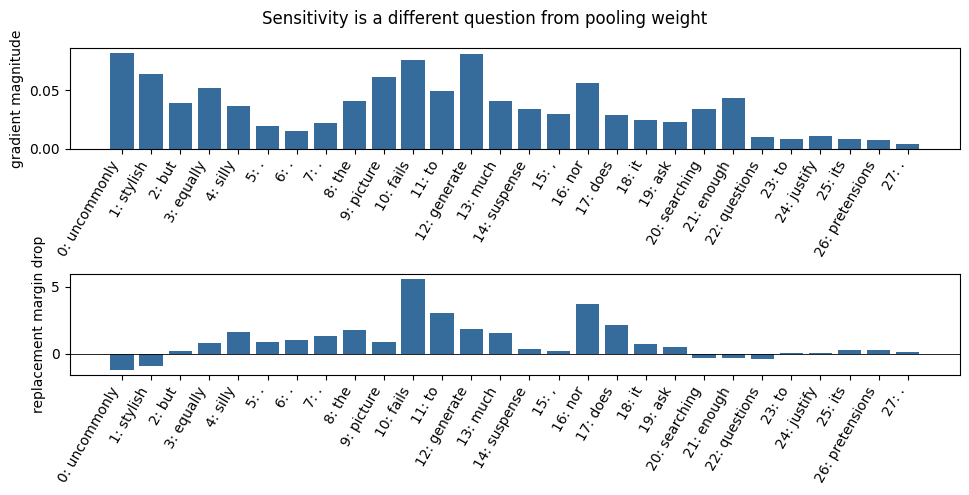

In [5]:
display(table[['position','token','attention','gradient_magnitude','replacement_margin_drop','replacement_probability_drop']].round(4))
print('Attention–gradient Spearman:',round(audit.spearman(table.attention,table.gradient_magnitude),3))
print('Attention–|replacement| Spearman:',round(audit.spearman(table.attention,table.replacement_margin_drop.abs()),3))
print('Gradient–|replacement| Spearman:',round(audit.spearman(table.gradient_magnitude,table.replacement_margin_drop.abs()),3))
print('Top-3 overlap:',round(audit.topk_overlap(table.attention,table.gradient_magnitude),3))
plot_tokens(table,['gradient_magnitude','replacement_margin_drop'],'Sensitivity is a different question from pooling weight')

## 5. Check the intervention itself

Replacing a word with the literal string `<UNK>` and re-tokenizing would split that string
into punctuation and letters. Instead, we replace exactly one ID with the unknown ID,
keeping sequence length and all other IDs fixed. We then **re-encode the whole sequence**.
Existing unknown tokens cannot be further changed by this replacement; their zero effect
does not establish that the original word was unimportant.

The intervention is replacement, not deletion. A deletion exercise is an optional alternative,
not a second name for the same operation. Probability changes and margin changes are both
reported because probabilities can saturate near 0 and 1.

In [6]:
high=int(table.attention.argmax());low=int(table.attention.argmin())
display(table.iloc[[high,low]][['position','token','is_unknown','attention','replacement_margin_drop','replacement_probability_drop']])
x,lens,mask,tokens=tensors(first.sentence,vocab)
changed=x.clone();changed[0,high]=vocab[audit.UNK]
print('Original IDs:',x.tolist())
print('One-token replacement IDs:',changed.tolist())
assert changed.shape==x.shape
assert int((changed!=x).sum()) <= 1

Original IDs: [[2169, 638, 27, 1009, 380, 7, 7, 7, 2, 195, 530, 10, 3600, 63, 413, 3, 558, 61, 15, 1804, 2892, 85, 1150, 10, 3676, 21, 4469, 7]]
One-token replacement IDs: [[2169, 638, 27, 1009, 380, 7, 7, 7, 2, 195, 530, 10, 3600, 63, 413, 3, 1, 61, 15, 1804, 2892, 85, 1150, 10, 3676, 21, 4469, 7]]


,position,token,is_unknown,attention,replacement_margin_drop,replacement_probability_drop
16,16,nor,False,0.230402,3.713005,0.720022
7,7,.,False,0.000008,1.326905,0.195405


**Discuss:** does the higher-attention token always have the larger effect? If not, what
could explain the difference besides a broken implementation?

## 6. Hold the hidden states fixed and change attention

Now freeze the encoder output and change only the pooling weights: one uniform distribution
and 30 deterministic random permutations. These are internal interventions, not fluent edits
or proof that another naturally trained model would generate these weights.

Measure attention **total variation distance**, $TV=\frac12\sum_i|\alpha_i-\tilde\alpha_i|$,
alongside output changes. TV ranges from 0 to 1. A shuffled distribution is not necessarily
different; near-uniform attention can remain near-identical after shuffling.

A changed class is strong sensitivity evidence, but an unchanged class can conceal a large
score change. Conversely, a tiny probability change may conceal a substantial margin change.

attention_tv          ... label_changed       
                mean     max  ...          mean    max
kind                          ...                     
shuffle       0.7837  0.9767  ...           0.0  False
uniform       0.7505  0.7505  ...           0.0  False

[2 rows x 8 columns]

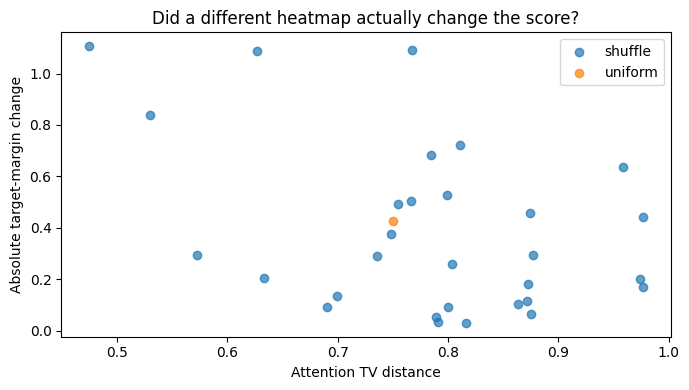

In [7]:
local_trials=attention_audit(model,first.sentence,vocab,seed=2026,n_shuffles=30)
display(local_trials.groupby('kind')[['attention_tv','abs_probability_change','abs_margin_change','label_changed']].agg(['mean','max']).round(4))
fig,ax=plt.subplots(figsize=(7,4))
for kind,g in local_trials.groupby('kind'):
    ax.scatter(g.attention_tv,g.abs_margin_change,label=kind,alpha=.7)
ax.set(xlabel='Attention TV distance',ylabel='Absolute target-margin change',title='Did a different heatmap actually change the score?');ax.legend()
plt.tight_layout();plt.show()

## 7. Move from one example to a fixed cohort

The 120 validation IDs were selected with random seed 2026 before seeing explanation results.
All model seeds use those same IDs and permutation seeds. Below are saved outputs of the shared
audit functions, not invented teaching numbers. Rerun `run_case7_experiments.py` to regenerate
the full cohort; the notebook recomputes the detailed examples live.

For correlations, compare magnitudes rather than interpreting attention as signed support.
Spearman is undefined for constant vectors; report valid counts. Top-3 overlap is easier by
chance on short sentences: the independent random-set expectation is min(3,n)/n.
It is a reference, not a significance test.

,count,mean,median,min,max
attention_gradient_rho,120.0,0.492955,0.490817,-0.272727,1.0
attention_replacement_rho,120.0,0.38888,0.408616,-0.8,0.923077
gradient_replacement_rho,120.0,0.426548,0.444581,-0.6,0.942857
top3_overlap,120.0,0.630556,0.666667,0.333333,1.0
top3_chance_overlap,120.0,0.206124,0.176471,0.071429,0.75
uniform_tv,120.0,0.740859,0.749056,0.314202,0.941963
uniform_abs_dp,120.0,0.115114,0.034511,0.000031,0.700215
uniform_abs_dm,120.0,1.567114,1.364572,0.052326,5.931802
uniform_flip,120,0.116667,0.0,False,True
shuffle_mean_tv,120.0,0.830643,0.845637,0.337333,0.97966


,confidence,attention_gradient_rho,uniform_abs_dm,uniform_flip
correct,,,,
False,0.8080,0.5009,1.1958,0.1250
True,0.9271,0.4910,1.6599,0.1146


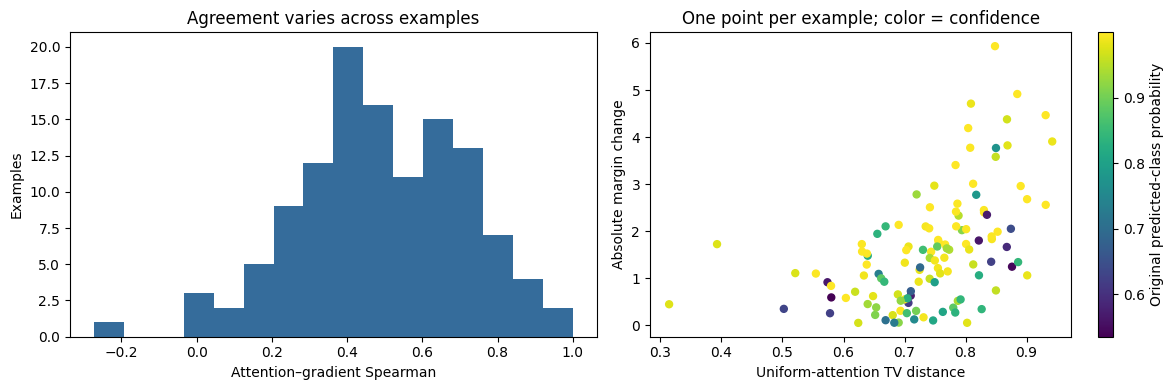

In [8]:
cols=['attention_gradient_rho','attention_replacement_rho','gradient_replacement_rho',
      'top3_overlap','top3_chance_overlap','uniform_tv','uniform_abs_dp','uniform_abs_dm','uniform_flip',
      'shuffle_mean_tv','shuffle_mean_abs_dp','shuffle_mean_abs_dm','shuffle_flip_rate']
display(aggregate[cols].agg(['count','mean','median','min','max']).T.round(4))
display(aggregate.groupby('correct')[['confidence','attention_gradient_rho','uniform_abs_dm','uniform_flip']].mean().round(4))
fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].hist(aggregate.attention_gradient_rho.dropna(),bins=16,color='#356c9b')
axes[0].set(xlabel='Attention–gradient Spearman',ylabel='Examples',title='Agreement varies across examples')
points=axes[1].scatter(aggregate.uniform_tv,aggregate.uniform_abs_dm,c=aggregate.confidence,cmap='viridis',s=25)
fig.colorbar(points,ax=axes[1],label='Original predicted-class probability')
axes[1].set(xlabel='Uniform-attention TV distance',ylabel='Absolute margin change',title='One point per example; color = confidence')
plt.tight_layout();plt.show()

**Interpretation checkpoint:** which observations support a role for attention? Which limit
the claim that its highlighted words are the full explanation? Use numerical results.
Thirty shuffles of the same sentence are not thirty independent sentences.

## 8. Inspect disagreement and a model error

We select the correctly classified audited example (6–35 tokens) with the lowest
attention–gradient correlation. This is a reproducible **extreme example**, not a representative
sample and not evidence that disagreement is typical. Then we inspect the highest-confidence
error of that length. Selection rules are explicit so they can be challenged.

Selected disagreement: it 's a charming and often affecting journey .  rho: -0.273
Selected error: due to some script weaknesses and the casting of the director 's brother , the film trails off into inconsequentiality . 
Reference: 0 prediction: 1 confidence: 1.0


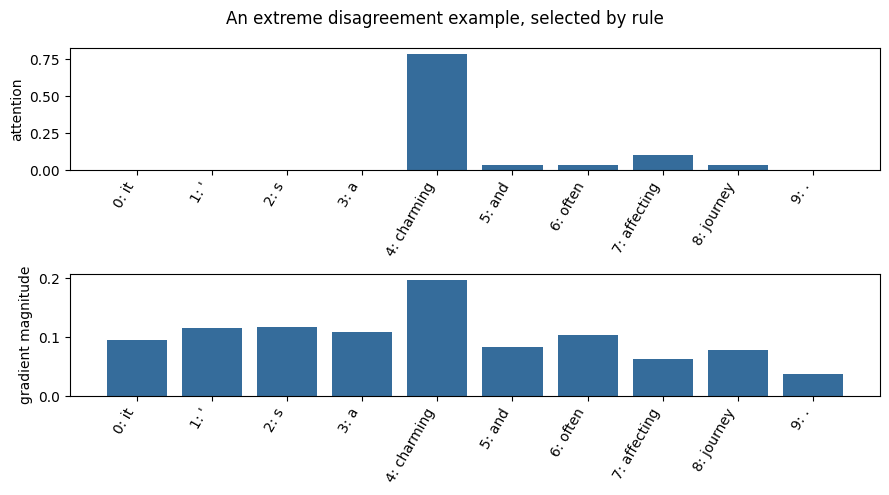

,position,token,attention,replacement_margin_drop
7,7,casting,0.686313,1.662853
4,4,weaknesses,0.280915,1.099718
10,10,director,0.011810,0.417449
5,5,and,0.007706,1.312267
8,8,of,0.004812,1.519639
3,3,script,0.003689,0.210693
0,0,due,0.001620,1.643195
2,2,some,0.001137,2.471216


In [9]:
pool=aggregate[aggregate.correct & aggregate.n_tokens.between(6,35)].dropna(subset=['attention_gradient_rho'])
if len(pool):
    row=pool.sort_values(['attention_gradient_rho','idx']).iloc[0]
    ex=pred[pred.idx==row.idx].iloc[0]
    t,inf=token_audit(model,ex.sentence,vocab)
    print('Selected disagreement:',ex.sentence,'rho:',round(row.attention_gradient_rho,3))
    plot_tokens(t,['attention','gradient_magnitude'],'An extreme disagreement example, selected by rule')
else: print('No eligible disagreement example; do not fabricate one.')
errors=pred[(~pred.correct) & pred.n_tokens.between(6,35)].sort_values(['confidence','idx'],ascending=[False,True])
if len(errors):
    error=errors.iloc[0];et,ei=token_audit(model,error.sentence,vocab)
    print('Selected error:',error.sentence)
    print('Reference:',error.label,'prediction:',ei['target'],'confidence:',round(ei['target_probability'],4))
    display(et.sort_values('attention',ascending=False)[['position','token','attention','replacement_margin_drop']].head(8))
else: print('No error in the selected length range.')

**Question:** can an explanation faithfully describe an incorrect prediction? Separate the
truth of the review label from the behavior of the model.

## 9. Language composition: a diagnostic slice and controlled probes

The cue-word slice (`not`, `never`, `but`, `however`, `although`, `though`, `yet`, `n't`)
is only a rough proxy for negation/contrast. Report its size and accuracy before choosing
an example. A correct sentence containing “not” does not establish negation understanding.

The following short pairs are **handwritten probes**, not SST-2 benchmark items. Their
purpose is to ask whether one intuitive wording change has the expected direction.
They are not a general language-understanding test. Discuss alternatives when human meaning
is ambiguous, and inspect unknown tokens before judging a failure.

In [10]:
cue=pred.sentence.str.contains(r"\b(?:not|never|but|however|although|though|yet)\b|n't",case=False,regex=True)
display(pred.assign(cue_slice=cue).groupby('cue_slice').agg(n=('correct','size'),accuracy=('correct','mean')))
probes=['the film is good','the film is not good','the film is bad','the film is not bad',
        'the acting is good but the story is terrible','the acting is terrible but the story is good']
probe_rows=[]
for text in probes:
    t,inf=token_audit(model,text,vocab)
    pp=inf['target_probability'] if inf['target']==1 else 1-inf['target_probability']
    probe_rows.append({'text':text,'P(positive)':pp,'unknown_tokens':int(t.is_unknown.sum())})
display(pd.DataFrame(probe_rows))

,n,accuracy
cue_slice,,
False,638,0.794671
True,234,0.726496


,text,P(positive),unknown_tokens
0,the film is good,0.999622,0
1,the film is not good,0.055193,0
2,the film is bad,0.065633,0
3,the film is not bad,0.020406,0
4,the acting is good but the story is terrible,0.906421,0
5,the acting is terrible but the story is good,0.994449,0


## 10. Optional: separate pooling weight from class contribution

Because this model has a linear classifier after pooling (dropout disabled for evaluation),
the target-class margin decomposes exactly as:

$$m=b_t-b_o+\sum_i\alpha_i (w_t-w_o)^T h_i.$$

The sign and size of the projected hidden state matter as well as attention. This is an
exact accounting identity **conditional on the hidden states**. It does not establish the
causal contribution of the isolated word, since each state is contextual.

In [11]:
display(table[['position','token','attention','conditional_margin_contribution']].round(4))
reconstructed=table.conditional_margin_contribution.sum()+info['bias_margin']
print('Actual margin:',info['target_margin'],'reconstructed:',reconstructed)
assert np.isclose(reconstructed,info['target_margin'],atol=1e-5)

Actual margin: 2.1953890323638916 reconstructed: 2.195389


,position,token,attention,conditional_margin_contribution
0,0,uncommonly,0.1718,0.0020
1,1,stylish,0.1095,-0.1956
2,2,but,0.0004,-0.0001
3,3,equally,0.0010,0.0005
4,4,silly,0.0007,0.0020
5,5,.,0.0000,0.0001
6,6,.,0.0000,0.0000
7,7,.,0.0000,0.0000
8,8,the,0.0000,0.0001
9,9,picture,0.0016,0.0052


## 11. Optional: stability across model seeds

All three models use the same vocabulary, data, four-epoch recipe, audit IDs, and intervention
seeds. The initialization and training shuffle vary. No “best explanation” seed is selected:
2026 is the classroom model fixed in advance. Three seeds give limited evidence of variation;
they do not establish robustness across architectures or datasets.

In [12]:
seeds=pd.read_csv(OUT/'seed_summary.csv')
display(seeds[['seed','accuracy','attention_gradient_rho','attention_replacement_rho',
              'uniform_abs_dp','uniform_abs_dm','uniform_flip','shuffle_flip_rate']].round(4))

,seed,accuracy,attention_gradient_rho,attention_replacement_rho,uniform_abs_dp,uniform_abs_dm,uniform_flip,shuffle_flip_rate
0,2026,0.7764,0.4930,0.3889,0.1151,1.5671,0.1167,0.1375
1,2027,0.7901,0.5894,0.4575,0.0859,1.3985,0.0583,0.1042
2,2028,0.7787,0.5082,0.2993,0.1087,1.6120,0.0667,0.1211


## 12. Write the stakeholder verdict

| Claim | Evidence needed |
|---|---|
| Correctness | Agreement with reference labels, including errors |
| Confidence | Model score; no automatic claim of calibration |
| Plausibility | A human judgment, not established by model metrics alone |
| Faithfulness | Precisely specified diagnostics and interventions, with limitations |

Write 150–200 words for the hypothetical review platform:

1. State the claim you audited and name the model/data scope.
2. Cite two numerical results, including a distribution or across-seed observation.
3. Explain what supports the highlight **if such evidence was observed**.
4. Explain what limits it **if such evidence was observed**.
5. State one unresolved question and propose a test addressing it.
6. Recommend wording for the UI: for example “attention pooling weights” is a narrower
   claim than “the words that caused the decision.”

Do not force the verdict toward “attention is the explanation” or “attention is useless.”
An unchanged class alone is insufficient evidence of an unchanged prediction score.

**Exit ticket:** explain the difference between replacing an input token and changing attention
while holding hidden states fixed, in two sentences.

## Research lineage and curriculum alignment

This independent teaching adaptation follows the supplied deep-learning lecture's attention
questions (slides 6–12), gradient/leave-one-out comparison (19), alternative attention and
permutation tests (23–25), and contextual/architecture limitations (27–28).
Our UNK replacement is explicitly distinct from literal leave-one-out deletion.
We do not claim to reproduce the papers' architectures, datasets, or exact experimental protocols.

- Socher et al. (2013), [SST](https://aclanthology.org/D13-1170/).
- Jain & Wallace (2019), [Attention is not Explanation](https://aclanthology.org/N19-1357/).
- Wiegreffe & Pinter (2019), [Attention is not not Explanation](https://aclanthology.org/D19-1002/).

Read the latter two as a methodological debate. Our empirical verdict belongs to this run.